In [91]:
import os
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

sys.path.append("../utility")
from model_performance_classification import evaluate_model

warnings.filterwarnings("ignore")


In [92]:
data_path = os.path.join("..", "data", "clean_data", "encoded_tree_dataset_final.csv")
df = pd.read_csv(data_path)
df.head()

,State_Province,City,Latitude,Longitude,Elevation,Tree_Name,Tree_Age,Height_Meter,Trunk_Diameter_cm,Canopy_Width_m,...,Inspection_Frequency,Tree_Health_Status,Growth_Rate_m_per_year,Expected_Total_Lifespan_Years,Carbon_Absorption_kg,Survival_Probability,Soil_Type_Clayey,Soil_Type_Loamy,Soil_Type_Saline,Soil_Type_Sandy
0,0.03210,0.03210,23.017811,72.567292,53,0.02000,78,20.71,51.77,14.34,...,2,0,0.306,95,79.97,0.96,1,0,0,0
1,0.03250,0.03250,30.902437,75.867032,247,0.01945,70,17.82,44.54,12.34,...,2,0,0.581,95,68.83,1.00,1,0,0,0
2,0.03380,0.03380,28.621786,77.199431,217,0.02105,94,19.49,48.72,13.49,...,2,0,0.405,95,74.39,0.99,0,0,0,0
3,0.03470,0.03470,24.816504,93.940258,783,0.02070,19,13.63,34.07,9.44,...,2,0,0.570,95,54.78,0.99,0,0,1,0
4,0.03045,0.03045,12.980502,77.596770,920,0.01930,50,19.69,49.22,13.63,...,2,0,0.650,95,75.96,1.00,1,0,0,0


In [93]:
# Feature selection
soil_cols = [col for col in df.columns if col.startswith("Soil_Type_")]

selected_features = [
    "Tree_Name",
    "Tree_Age",
    "Height_Meter",
    "Trunk_Diameter_cm",
    "Canopy_Width_m",
    "Root_Depth_m",
    "Growth_Stage",
    "Temperature_C",
    "Rainfall_mm",
    "Humidity_Pct",
    "Drought_Index",
    "AQI",
    "PM2_5",
    "PM10",
    "CO_Level",
    "NO2_Level",
    "SO2_Level",
    "Soil_pH",
    "Nitrogen",
    "Phosphorus",
    "Potassium",
    "Organic_Carbon",
    "Leaf_Color",
    "Leaf_Drop_Percentage",
    "Pest_Presence",
    "Disease_Symptoms",
    "Bark_Damage",
    "Root_Condition",
    "Water_Stress_Index",
    "Fungal_Infection",
    "Watering_Frequency",
    "Pruning_Count",
    "Treatment_History",
    "Inspection_Frequency"
]

selected_features.extend(soil_cols)

X = df[selected_features]
y = df["Tree_Health_Status"]

In [94]:
# train test split data

from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [95]:
# handle inbalanced classes use SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled , y_resampled = smote.fit_resample(X_train,y_train)

In [96]:
y_resampled.value_counts()

Tree_Health_Status
0    10112
3    10112
2    10112
1    10112
Name: count, dtype: int64

## RandomForestClassifier

In [97]:
rfc = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    
)

rfc.fit(X_resampled,y_resampled)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fash

In [98]:
print(f"Traing Score : {rfc.score(X_resampled,y_resampled)}")
print(f"Testing Score : {rfc.score(X_test,y_test)}")

Traing Score : 0.9987885680379747
Testing Score : 0.96225


In [99]:
y_pred_rfc = rfc.predict(X_test)

In [100]:

rfc_model_per = evaluate_model(y_test, y_pred_rfc)
rfc_model_per

{'Accuracy': 0.96225,
 'Balanced Accuracy': 0.9433535031605331,
 'Precision': 0.9658863590042106,
 'Recall': 0.96225,
 'F1 Score': 0.9626103028030637}

In [101]:

from sklearn.metrics import classification_report

print(f"Classification Report : {classification_report(y_test,y_pred_rfc)}")

Classification Report :               precision    recall  f1-score   support

           0       1.00      0.96      0.98      2528
           1       0.98      0.85      0.91       268
           2       0.89      1.00      0.94      1088
           3       0.89      0.97      0.93       116

    accuracy                           0.96      4000
   macro avg       0.94      0.94      0.94      4000
weighted avg       0.97      0.96      0.96      4000



In [102]:
# Calculate ROC-AUC for Multi-Class Classification
from sklearn.metrics import roc_auc_score

y_prob = rfc.predict_proba(X_test)

rfc_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class='ovr',  
    average='weighted'
)

print("ROC-AUC Score:", rfc_auc)

ROC-AUC Score: 0.9991519634217582


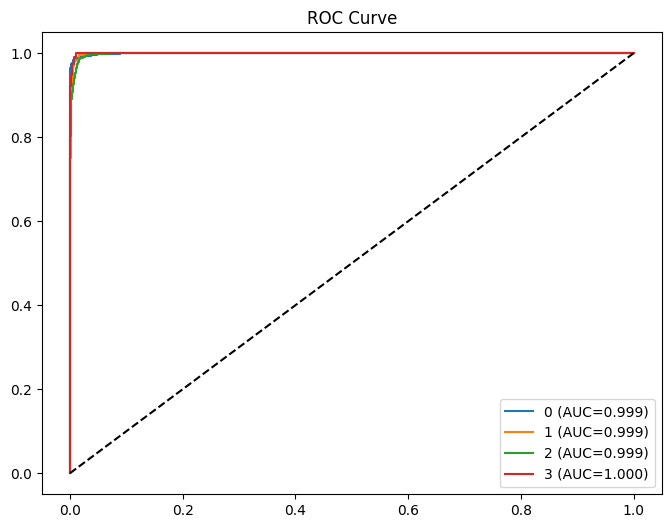

In [103]:
# Plot ROC Curve for Each Class

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

class_names = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=class_names)

plt.figure(figsize=(8,6))

for i in range(len(class_names)):
    if np.sum(y_test_bin[:, i]) == 0:
        continue

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve")
plt.show()

In [104]:
# features importance
rfc_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rfc.feature_importances_
})

rfc_importance.sort_values(
    by='Importance',
    ascending=False
).head(15)

,Feature,Importance
27,Root_Condition,0.240331
23,Leaf_Drop_Percentage,0.115472
33,Inspection_Frequency,0.080019
28,Water_Stress_Index,0.079545
32,Treatment_History,0.061020
31,Pruning_Count,0.056827
26,Bark_Damage,0.056669
21,Organic_Carbon,0.043062
30,Watering_Frequency,0.042064
24,Pest_Presence,0.040296


In [105]:
# Cross validation
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

rfc_skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rfc_cv_scores = cross_val_score(
    rfc,
    X_resampled,
    y_resampled,
    cv=rfc_skf,
    scoring='f1_weighted'
)

print("CV Scores:", rfc_cv_scores)
print("Mean CV Score:", np.mean(rfc_cv_scores))

CV Scores: [0.98506849 0.98395312 0.9793936  0.98381941 0.98443705]
Mean CV Score: 0.9833343371795491


In [238]:
# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [200, 300, 500, 800, 1000],
    'max_depth': [10, 15, 20, 25, 30, None],
    'min_samples_split': [2, 3, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rfc_random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1
)


rfc_random_search.fit(X_resampled, y_resampled)

print(f"Best Parameters: {rfc_random_search.best_params_}")
print(f"Best CV Score : {rfc_random_search.best_score_}")

Best Parameters: {'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced'}
Best CV Score : 0.8525521828154998


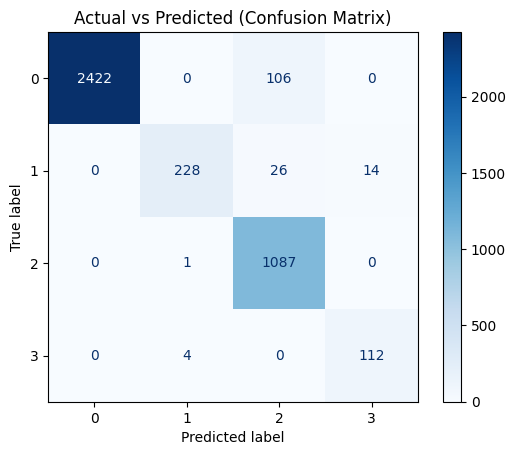

In [106]:
# Actual class v/s Predicted class
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rfc,
    cmap='Blues'
)

plt.title("Actual vs Predicted (Confusion Matrix)")
plt.show()


## XGBoostClassifier

In [107]:
xgbc = XGBClassifier(
    objective='multi:softprob',
    num_class=len(np.unique(y)),
    n_estimators=500,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)

xgbc.fit(X_resampled,y_resampled)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import l

In [108]:
print(f"Traing Score : {xgbc.score(X_resampled,y_resampled)}")
print(f"Testing Score : {xgbc.score(X_test,y_test)}")

Traing Score : 0.9999505537974683
Testing Score : 0.986


In [109]:
y_pred_xgbc = xgbc.predict(X_test)

In [110]:
# model performance
xgbc_model_per = evaluate_model(y_test,y_pred_xgbc)
xgbc_model_per

{'Accuracy': 0.986,
 'Balanced Accuracy': 0.9800023725075677,
 'Precision': 0.9863368909294593,
 'Recall': 0.986,
 'F1 Score': 0.9860640153962864}

In [111]:

print(f"Classification Report : {classification_report(y_test,y_pred_xgbc)}")


Classification Report :               precision    recall  f1-score   support

           0       1.00      0.98      0.99      2528
           1       0.97      0.97      0.97       268
           2       0.96      0.99      0.98      1088
           3       0.95      0.97      0.96       116

    accuracy                           0.99      4000
   macro avg       0.97      0.98      0.98      4000
weighted avg       0.99      0.99      0.99      4000



In [112]:
# Calculate ROC-AUC for Multi-Class Classification

y_prob_xgb = xgbc.predict_proba(X_test)

xgb_auc = roc_auc_score(
    y_test,
    y_prob_xgb,
    multi_class='ovr',  
    average='weighted'
)

print("ROC-AUC:", round(xgb_auc, 4))

ROC-AUC: 0.9998


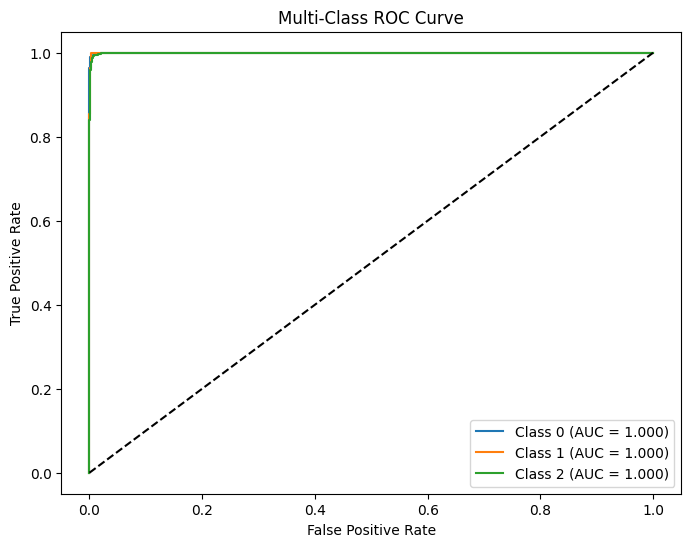

In [113]:
# Plot ROC Curve for Each Class

y_test_xgb_bin = label_binarize(y_test, classes=range(len(class_names)))

plt.figure(figsize=(8,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_xgb_bin[:, i], y_prob_xgb[:, i])
    acu_value = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'Class {i} (AUC = {acu_value:.3f})'
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve')
plt.legend()
plt.show()

In [114]:
# features importance
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgbc.feature_importances_
})
xgb_importance.sort_values(
    by="Importance",
    ascending=False
).head(20)

,Feature,Importance
22,Leaf_Color,0.438825
27,Root_Condition,0.202910
31,Pruning_Count,0.142259
24,Pest_Presence,0.114731
23,Leaf_Drop_Percentage,0.041951
28,Water_Stress_Index,0.017856
21,Organic_Carbon,0.007849
32,Treatment_History,0.003143
34,Soil_Type_Clayey,0.002833
35,Soil_Type_Loamy,0.002301


In [115]:
# cross validation

xgbc_skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgbc_cv_scores = cross_val_score(
    xgbc,
    X_resampled,
    y_resampled,
    cv=xgbc_skf,
    scoring='f1_weighted'
)

print("CV Scores:", xgbc_cv_scores)
print("Mean CV Score:", np.mean(xgbc_cv_scores))

CV Scores: [0.99233803 0.99320039 0.9903566  0.99171562 0.99233483]
Mean CV Score: 0.991989094403953


In [251]:
# Hyperparameter Tuning 
param_grid = {
    'n_estimators': [300, 500, 800, 1000],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2, 0.3]
}

xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss'
)

xgbc_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=50,
    scoring='f1_weighted',
    cv=5,
    random_state=42,
    n_jobs=-1
)

xgbc_search.fit(X_resampled, y_resampled)

print(f"Best parameters : {xgbc_search.best_params_}")
print(f"Best CV Score ; {xgbc_search.best_score_}")

Best parameters : {'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 0.8}
Best CV Score ; 0.9863162954606528


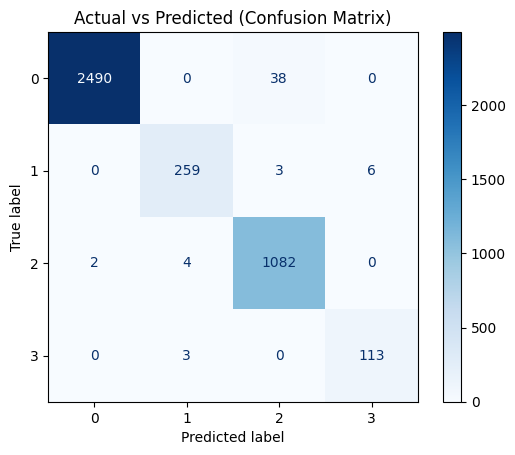

In [116]:
# Actual class v/s Predicated class
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgbc,
    cmap='Blues'
)

plt.title("Actual vs Predicted (Confusion Matrix)")
plt.show()

In [117]:
xgb_predication = pd.DataFrame({
    "Actual value ": y_test,
    "predicated value " : y_pred_xgbc
}
)
xgb_predication.head(15)

,Actual value,predicated value
17754,2,2
16723,0,0
180,1,1
17180,0,0
9015,0,0
17894,3,3
16177,0,0
8349,0,0
1086,0,0
17246,0,0


## CatBoostClassifier

In [118]:
from catboost import CatBoostClassifier

In [119]:
cat = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=3,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=0
)
cat.fit(X_resampled,y_resampled)

CatBoostClassifier(depth=6, eval_metric='Accuracy', iterations=500, l2_leaf_reg=3, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=0)

In [121]:
print(f"Traing Score : {cat.score(X_resampled,y_resampled)}")
print(f"Testing Score : {cat.score(X_test,y_test)}")

Traing Score : 0.9911985759493671
Testing Score : 0.98575


In [122]:
y_pred_cat = cat.predict(X_test)

In [123]:
# model performance

cat_model_per = evaluate_model(y_test,y_pred_cat)
cat_model_per

{'Accuracy': 0.98575,
 'Balanced Accuracy': 0.9827408143084038,
 'Precision': 0.9862678099231954,
 'Recall': 0.98575,
 'F1 Score': 0.9858315279131319}

In [124]:

print(f"Classification Report : {classification_report(y_test,y_pred_cat)}")

Classification Report :               precision    recall  f1-score   support

           0       1.00      0.98      0.99      2528
           1       0.98      0.96      0.97       268
           2       0.96      1.00      0.98      1088
           3       0.93      0.99      0.96       116

    accuracy                           0.99      4000
   macro avg       0.97      0.98      0.98      4000
weighted avg       0.99      0.99      0.99      4000



In [125]:
# Calculate ROC-AUC for Multi-Class Classification

y_prob_cat = cat.predict_proba(X_test)

cat_auc = roc_auc_score(
    y_test,
    y_prob_cat,
    multi_class='ovr',  
    average='weighted'
)

print("ROC-AUC:", round(cat_auc, 4))

ROC-AUC: 0.9998


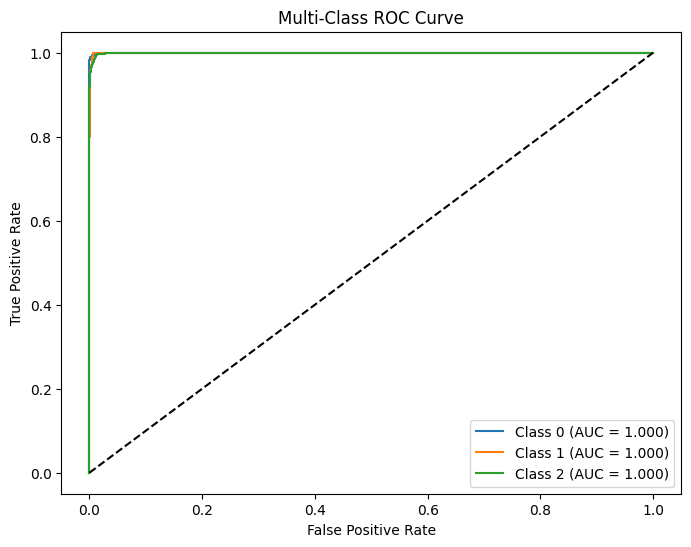

In [126]:
# Plot ROC Curve for Each Class

y_test_cat_bin = label_binarize(y_test, classes=range(len(class_names)))

plt.figure(figsize=(8,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_cat_bin[:, i], y_prob_cat[:, i])
    acu_value = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'Class {i} (AUC = {acu_value:.3f})'
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve')
plt.legend()
plt.show()

In [127]:
# features importance
cat_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": cat.feature_importances_
})
cat_importance.sort_values(
    by="Importance",
    ascending=False
).head(15)

,Feature,Importance
27,Root_Condition,19.572890
23,Leaf_Drop_Percentage,14.974144
21,Organic_Carbon,14.206448
28,Water_Stress_Index,8.257648
24,Pest_Presence,7.677721
32,Treatment_History,5.158955
33,Inspection_Frequency,4.872596
22,Leaf_Color,4.534870
31,Pruning_Count,2.986826
8,Rainfall_mm,2.382953


In [128]:
# cross validation

cat_skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cat_cv_scores = cross_val_score(
    cat,
    X_resampled,
    y_resampled,
    cv=cat_skf,
    scoring='f1_weighted'
)

print("CV Scores:", cat_cv_scores)
print("Mean CV Score:", np.mean(cat_cv_scores))

CV Scores: [0.98875139 0.98689891 0.98554417 0.98664661 0.9885028 ]
Mean CV Score: 0.9872687752901008


In [ ]:
# hyperparameter Tuning
param_grid = {
    'iterations': [300, 500, 800, 1000],
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5, 7, 10],
    'bagging_temperature': [0, 1, 3, 5],
    'random_strength': [1, 2, 5, 10]
}

catc = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=0
)

cat_search = RandomizedSearchCV(
    estimator=catc,
    param_distributions=param_grid,
    n_iter=30,
    scoring='f1_weighted',
    cv=5,
    random_state=42,
    n_jobs=-1
)

cat_search.fit(X_resampled, y_resampled)

print(f"Best Parameters : {cat_search.best_params_}")

print(f"Best CV Score : {cat_search.best_score_}")

KeyboardInterrupt: 

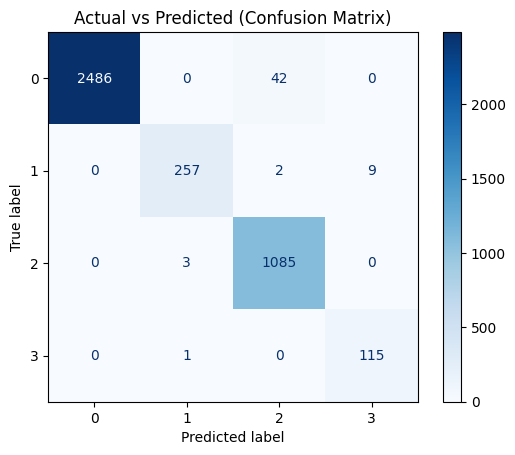

In [129]:
# Actual class v/s Predicated class
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_cat,
    cmap='Blues'
)

plt.title("Actual vs Predicted (Confusion Matrix)")
plt.show()

## Model Performance Comparison

In [130]:
results = []

results.append([
    "Random Forest",
    rfc.score(X_resampled, y_resampled),
    rfc.score(X_test, y_test),
    rfc_model_per["Accuracy"],
    rfc_model_per["Precision"],
    rfc_model_per["Recall"],
    rfc_model_per["F1 Score"],
    rfc_auc
])

results.append([
    "XGBoost",
    xgbc.score(X_resampled, y_resampled),
    xgbc.score(X_test, y_test),
    xgbc_model_per["Accuracy"],
    xgbc_model_per["Precision"],
    xgbc_model_per["Recall"],
    xgbc_model_per["F1 Score"],
    xgb_auc
])

results.append([
    "CatBoost",
    cat.score(X_resampled, y_resampled),
    cat.score(X_test, y_test),
    cat_model_per["Accuracy"],
    cat_model_per["Precision"],
    cat_model_per["Recall"],
    cat_model_per["F1 Score"],
    cat_auc
])

comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Training Score",
        "Testing Score",
        "Accuracy Score",
        "Precision Score",
        "Recall Score",
        "F1 Score",
        "ROC AUC"
    ]
)

comparison = comparison.sort_values(
    by=["F1 Score", "ROC AUC"],
    ascending=False
)

comparison

,Model,Training Score,Testing Score,Accuracy Score,Precision Score,Recall Score,F1 Score,ROC AUC
1,XGBoost,0.999951,0.98600,0.98600,0.986337,0.98600,0.986064,0.999789
2,CatBoost,0.991199,0.98575,0.98575,0.986268,0.98575,0.985832,0.999807
0,Random Forest,0.998789,0.96225,0.96225,0.965886,0.96225,0.962610,0.999152


## Cross Validation Mean Comparison

In [131]:
cv_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "CatBoost"
    ],
    "CV Mean F1": [
        np.mean(rfc_cv_scores),
        np.mean(xgbc_cv_scores),
        np.mean(cat_cv_scores)
    ],
    "CV Std": [
        np.std(rfc_cv_scores),
        np.std(xgbc_cv_scores),
        np.std(cat_cv_scores)
    ]
})

cv_comparison.sort_values(
    by="CV Mean F1",
    ascending=False,
    inplace=True
)
cv_comparison.reset_index(drop=True, inplace=True)


## Final Model Comparison Table

In [132]:
final_comparison = comparison.merge(
    cv_comparison,
    on="Model"
)

final_comparison.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Training Score,Testing Score,Accuracy Score,Precision Score,Recall Score,F1 Score,ROC AUC,CV Mean F1,CV Std
0,XGBoost,0.999951,0.98600,0.98600,0.986337,0.98600,0.986064,0.999789,0.991989,0.000943
1,CatBoost,0.991199,0.98575,0.98575,0.986268,0.98575,0.985832,0.999807,0.987269,0.001202
2,Random Forest,0.998789,0.96225,0.96225,0.965886,0.96225,0.962610,0.999152,0.983334,0.002018


## Save Model

In [134]:
import joblib

joblib.dump(cat, "../models/Tree_Health_Classification_Model_2.pkl")
joblib.dump(X.columns.tolist(), "../models/Tree_Health_Prediction_Feature_Columns_2.pkl")


['../models/Tree_Health_Prediction_Feature_Columns_2.pkl']